# BBEATSx Phase 3: Decomposition Fidelity & Component UQ — DGP 1

This notebook validates BBEATSx on **DGP 1: Linear Trend + Single Seasonality + AR(1) + Homoscedastic Noise**.
It measures the forecasting calibration battery and the empirical coverage of component-level credible bands.

## Google Colab Setup

In [1]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Setting up workspace...")
    import os
    if not os.path.abspath(".").endswith("simulations"):
        if not os.path.exists("BBEATSx"):
            !git clone https://github.com/hugogobato/BBEATSx.git
        !pip install ./BBEATSx
        %cd BBEATSx/simulations
    else:
        print("Already in simulations directory.")

import sys
import os
sys.path.append(os.path.abspath("."))
sys.path.append(os.path.abspath(".."))

Running in Google Colab. Setting up workspace...
Cloning into 'BBEATSx'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 59 (delta 14), reused 52 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 61.84 KiB | 12.37 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Processing ./BBEATSx
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for bbeatsx: filename=bbeatsx-0.1.0-py3-none-any.whl size=43805 sha256=531592a4a27a726f8469bbda50b07ceeb4a2ec68374bd61c583ef0268ee7b963
  Stored in directory: /tmp/pip-ephem-wheel-cache-od3y8qy4/wheels/56/65/89/682968e55e85784c7ae1d0dfd917fdbd4d9c71ec4a8220358b
Successfully built bbeatsx
/content/BBEATSx/simulations


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bbeatsx import BBEATSx, make_config
import utils

## Simulation Configuration

In [3]:
NUM_SIMULATIONS = 100  # Set to 100 for final results on Colab
HORIZON = 20
LEVEL = 0.95
print(f"Running {NUM_SIMULATIONS} trials for DGP 1...")

Running 100 trials for DGP 1...


## Run Simulations

In [4]:
dgp1_forecasts = []
dgp1_components = []

for i in range(NUM_SIMULATIONS):
    t, y, true_comps = utils.generate_dgp1(n=200, seed=i)
    n_train = len(y) - HORIZON
    y_train, y_test = y[:n_train], y[n_train:]

    cfg = make_config(
        periods=[(12, 3)],
        lags=(1,),
        trend="spline",
        errors="homo",
        num_gfr=50,
        num_burnin=200,
        num_mcmc=1000,
        seed=i
    )

    model = BBEATSx(cfg).fit(y_train)
    fc = model.forecast(HORIZON)

    dgp1_forecasts.append(utils.evaluate_forecast(y_test, fc, y_train, level=LEVEL))

    s = model.sampler_
    mean, std = s.y_mean_, s.y_std_
    in_sample_draws = s.in_sample_components()
    pred_in_sample = {
        "trend": mean + std * in_sample_draws["trend"],
        "seasonal": std * in_sample_draws["seasonal"],
        "generic": std * in_sample_draws["generic"]
    }
    comp_metrics_in = utils.evaluate_component_fidelity(
        true_comps, pred_in_sample, offset=s.fs.row_offset, level=LEVEL
    )

    pred_out_sample = {
        "trend": fc.components["trend"],
        "seasonal": fc.components["seasonal"],
        "generic": fc.components["generic"]
    }
    true_out_comps = {k: v[n_train:] for k, v in true_comps.items()}
    comp_metrics_out = utils.evaluate_component_fidelity(
        true_out_comps, pred_out_sample, offset=0, level=LEVEL
    )

    dgp1_components.append({
        "in_sample": comp_metrics_in,
        "out_sample": comp_metrics_out
    })

    if (i + 1) % 10 == 0:
        print(f"  Completed trial {i + 1}/{NUM_SIMULATIONS}")

  Completed trial 10/100
  Completed trial 20/100
  Completed trial 30/100
  Completed trial 40/100
  Completed trial 50/100
  Completed trial 60/100
  Completed trial 70/100
  Completed trial 80/100
  Completed trial 90/100
  Completed trial 100/100


## Results Summary

In [5]:
df_fc1 = pd.DataFrame(dgp1_forecasts)
print("\n--- DGP 1 Forecasting Calibration Battery ---")
print(df_fc1.mean().to_frame("Mean Metric"))

comp_in_rmse = {k: np.mean([t["in_sample"][k]["rmse"] for t in dgp1_components]) for k in ["trend", "seasonal", "generic"]}
comp_in_cov = {k: np.mean([t["in_sample"][k]["coverage"] for t in dgp1_components]) for k in ["trend", "seasonal", "generic"]}
comp_out_rmse = {k: np.mean([t["out_sample"][k]["rmse"] for t in dgp1_components]) for k in ["trend", "seasonal", "generic"]}
comp_out_cov = {k: np.mean([t["out_sample"][k]["coverage"] for t in dgp1_components]) for k in ["trend", "seasonal", "generic"]}

df_comp1 = pd.DataFrame({
    "In-Sample RMSE": comp_in_rmse,
    "In-Sample Coverage (95%)": comp_in_cov,
    "Out-of-Sample RMSE": comp_out_rmse,
    "Out-of-Sample Coverage (95%)": comp_out_cov
})
print("\n--- DGP 1 Component Fidelity (Plan §3.2) ---")
print(df_comp1)


# Save evaluation metrics to CSV files
df_fc1.to_csv("dgp1_bbeatsx_forecast_eval.csv", index_label="trial")

comp_rows = []
for idx, c in enumerate(dgp1_components):
    row = {
        "trial": idx
    }
    for sample in ["in_sample", "out_sample"]:
        for comp in ["trend", "seasonal", "generic"]:
            if comp in c[sample]:
                row[f"{sample}_{comp}_rmse"] = c[sample][comp]["rmse"]
                row[f"{sample}_{comp}_coverage"] = c[sample][comp]["coverage"]
    comp_rows.append(row)
df_comp_all = pd.DataFrame(comp_rows)
df_comp_all.to_csv("dgp1_bbeatsx_component_eval.csv", index=False)
print("Saved evaluation metrics to CSV files!")



--- DGP 1 Forecasting Calibration Battery ---
                Mean Metric
rmse               0.728257
smape              9.117868
mase               1.044353
crps               0.433038
pinball            0.226854
coverage           0.958000
interval_score     3.837538

--- DGP 1 Component Fidelity (Plan §3.2) ---
          In-Sample RMSE  In-Sample Coverage (95%)  Out-of-Sample RMSE  \
trend           0.765960                  0.578156            1.066957   
seasonal        0.678986                  0.707151            0.665501   
generic         0.793886                  0.541117            1.031291   

          Out-of-Sample Coverage (95%)  
trend                           0.6745  
seasonal                        0.7620  
generic                         0.4740  
Saved evaluation metrics to CSV files!


## Visualizations

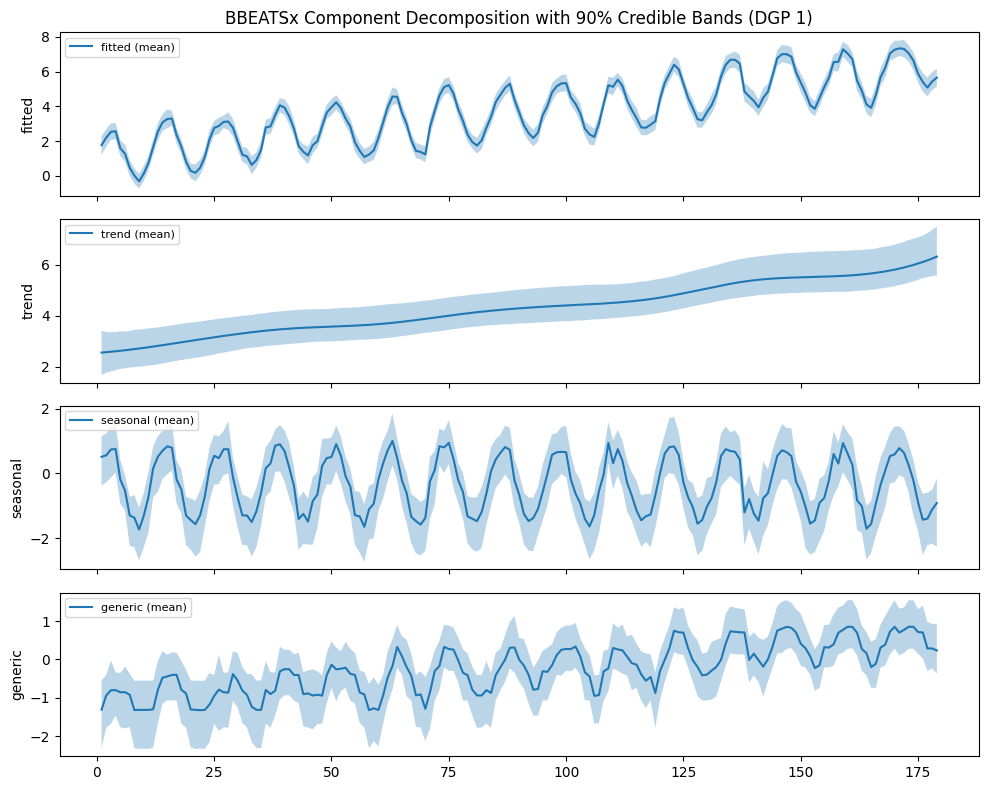

In [6]:
from bbeatsx.interpret import plot_decomposition

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
plot_decomposition(model.sampler_, level=LEVEL, ax=ax)
ax[0].set_title("BBEATSx Component Decomposition with 90% Credible Bands (DGP 1)")
plt.tight_layout()
plt.show()